# Artificial Neural Networks: Fundamentals

This section introduces the foundational concepts of artificial neural networks (ANNs), also known as feedforward neural networks. Understanding these basics is essential before exploring more specialized architectures like Convolutional Neural Networks (CNNs) used for magnetic field prediction.

## Neural Network Architecture

Neural Networks consist of collections of neurons that are connected in an acyclic graph. In other words, the outputs of neurons in a fully connected layer can become inputs to other neurons through pairwise connections. Cycles are not allowed since that could result in an infinite loop during the forward pass of a network. Additionally, any two neurons in a single hidden layer do not share any connections.
```{figure} ../_static/figures/CNN_NN.png
---
name: fig-ann-architecture
width: 65%
---
Artificial/Feedforward Neural Network with 2 hidden layers.
```

The architecture shown above depicts an ANN with two hidden layers. Each layer performs specific computations on the input data, progressively transforming it toward the desired output.

## Neuron Computation

Every node in a neural network computes a weighted sum of incoming inputs connecting the nodes of the previous layer. This operation can be visualized as merging all the weighted inputs entering a node to generate a single scalar value.

### Mathematical Formulation

For a neuron $j$ in layer $l$, the computation is:

$$
z_j^{(l)} = \sum_{i} w_{ji}^{(l)} a_i^{(l-1)} + b_j^{(l)}
$$

where:
- $w_{ji}^{(l)}$ are the weights connecting neuron $i$ from layer $(l-1)$ to neuron $j$ in layer $l$
- $a_i^{(l-1)}$ are the activations from the previous layer
- $b_j^{(l)}$ is the bias term
- $z_j^{(l)}$ is the pre-activation value

### Activation Functions

Every activation function (or non-linearity) takes this pre-activation value and performs a specific fixed mathematical operation on it:

$$
a_j^{(l)} = f(z_j^{(l)})
$$

Several activation functions are commonly used:

1. **ReLU (Rectified Linear Unit)**: $f(z) = \max(0, z)$
2. **Sigmoid**: $f(z) = \frac{1}{1 + e^{-z}}$
3. **Tanh**: $f(z) = \tanh(z)$
4. **Leaky ReLU**: $f(z) = \max(\alpha z, z)$ where $\alpha$ is small (e.g., 0.01)

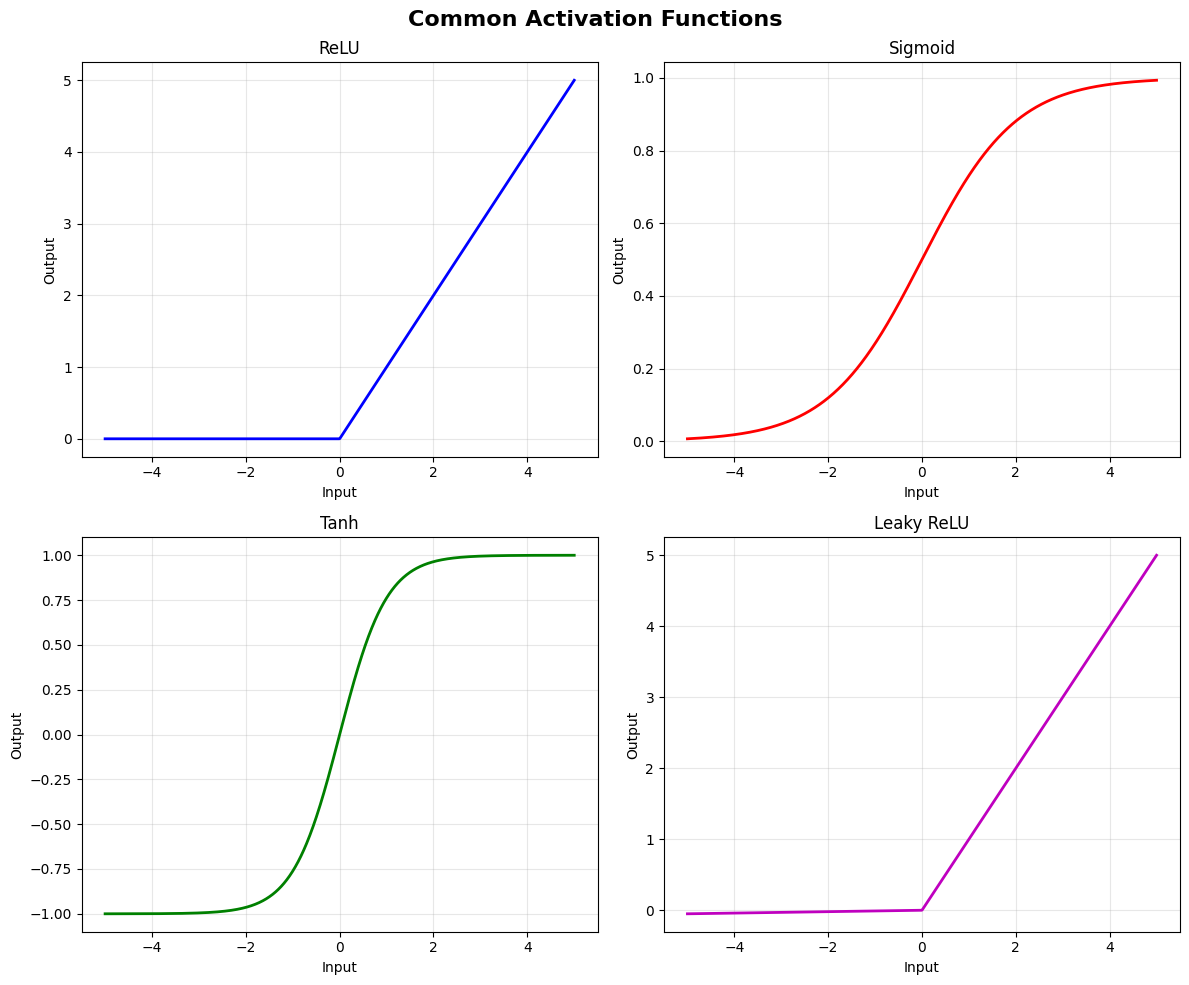

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate different activation functions
x = np.linspace(-5, 5, 1000)

# Define activation functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

# Plot activation functions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Common Activation Functions', fontsize=16, fontweight='bold')

axes[0, 0].plot(x, relu(x), 'b-', linewidth=2)
axes[0, 0].set_title('ReLU')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlabel('Input')
axes[0, 0].set_ylabel('Output')

axes[0, 1].plot(x, sigmoid(x), 'r-', linewidth=2)
axes[0, 1].set_title('Sigmoid')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlabel('Input')
axes[0, 1].set_ylabel('Output')

axes[1, 0].plot(x, tanh(x), 'g-', linewidth=2)
axes[1, 0].set_title('Tanh')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('Input')
axes[1, 0].set_ylabel('Output')

axes[1, 1].plot(x, leaky_relu(x), 'm-', linewidth=2)
axes[1, 1].set_title('Leaky ReLU')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Input')
axes[1, 1].set_ylabel('Output')

plt.tight_layout()
plt.show()

## Output Layer Characteristics

Unlike all other layers in a neural network, the output layer neurons most commonly do not have an activation function (or use a linear activation). This is because the output layer is usually taken to represent:

- **Classification**: Class scores which are arbitrary real-valued numbers
- **Regression**: Some real-valued target (as in our magnetic field prediction task)

For magnetic field prediction, we use the output layer without activation since we want to predict continuous field values directly.

## Loss Function

A loss function measures the quality of a particular set of parameters based on how well the induced scores agree with the ground truth target in the training data. The loss function is dependent on:

1. Training data (inputs and targets)
2. Weights and biases of the network

Since in machine learning we take the training data as given and fixed, and weights as variables that we can control, we use backpropagation to compute the gradients for the network parameters and perform parameter updates.

### Common Loss Functions

For regression tasks like magnetic field prediction:

**Mean Squared Error (MSE)**:
$$
L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**Root Mean Squared Error (RMSE)**:
$$
L = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

where $y_i$ is the true target value and $\hat{y}_i$ is the predicted value.

## Backpropagation

Backpropagation is a method for computing gradients of expressions through the recursive application of the **chain rule**. It enables efficient computation of how each weight in the network should be adjusted to minimize the loss function.

### Chain Rule

For a composition of functions $f(g(x))$, the chain rule states:

$$
\frac{df}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}
$$

In neural networks, this allows us to compute:

$$
\frac{\partial L}{\partial w_{ji}^{(l)}} = \frac{\partial L}{\partial a_j^{(l)}} \cdot \frac{\partial a_j^{(l)}}{\partial z_j^{(l)}} \cdot \frac{\partial z_j^{(l)}}{\partial w_{ji}^{(l)}}
$$

This gradient tells us how to adjust each weight to reduce the loss.

In [2]:
# Simple demonstration of forward and backward pass
class SimpleNeuralNetwork:
    """A minimal 2-layer neural network for demonstration"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        """Forward pass through the network"""
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = np.maximum(0, self.z1)  # ReLU activation

        # Layer 2 (output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.z2  # Linear activation for regression

        return self.a2

    def compute_loss(self, y_pred, y_true):
        """Compute MSE loss"""
        return np.mean((y_pred - y_true) ** 2)

# Create a simple network
np.random.seed(42)
network = SimpleNeuralNetwork(input_size=2, hidden_size=4, output_size=1)

# Sample data
X_sample = np.array([[1.0, 2.0]])
y_sample = np.array([[3.0]])

# Forward pass
y_pred = network.forward(X_sample)
loss = network.compute_loss(y_pred, y_sample)

print(f"Input: {X_sample}")
print(f"Predicted output: {y_pred[0, 0]:.4f}")
print(f"True output: {y_sample[0, 0]:.4f}")
print(f"Loss (MSE): {loss:.4f}")

Input: [[1. 2.]]
Predicted output: -0.0003
True output: 3.0000
Loss (MSE): 9.0019


### Understanding the Neural Network Implementation

Let's break down the key components of this simple neural network:

#### Weight Initialization (`__init__` method)

```python
self.W1 = np.random.randn(input_size, hidden_size) * 0.01
self.b1 = np.zeros((1, hidden_size))
```

**Key Points:**
- **Weights (`W1`, `W2`)**: Initialized with small random values (mean=0, std=0.01)
  - Random initialization breaks symmetry (neurons learn different features)
  - Small values (×0.01) prevent activation saturation early in training
  - Shape `(input_size, hidden_size)` means each input connects to each hidden neuron

- **Biases (`b1`, `b2`)**: Initialized to zero
  - Safe to start at zero (weights already broken symmetry)
  - Allows each neuron to shift its activation function

#### Forward Pass Computation

```python
self.z1 = np.dot(X, self.W1) + self.b1  # Pre-activation
self.a1 = np.maximum(0, self.z1)        # ReLU activation
```

**Step-by-step:**
1. **Linear transformation** (`np.dot(X, self.W1)`): Matrix multiplication computes weighted sum
   - If X is (batch_size, input_size) and W1 is (input_size, hidden_size)
   - Result is (batch_size, hidden_size) – one value per neuron per sample

2. **Add bias** (`+ self.b1`): Shifts the activation function
   - Broadcasting allows adding (1, hidden_size) to (batch_size, hidden_size)

3. **Apply ReLU** (`np.maximum(0, self.z1)`): Introduces non-linearity
   - Negative values become 0, positive values pass through unchanged
   - Without non-linearity, network would be equivalent to single linear layer

4. **Output layer** (`self.z2`): No activation for regression
   - Allows predicting any real-valued number
   - For classification, would use softmax or sigmoid here

#### Loss Computation

```python
return np.mean((y_pred - y_true) ** 2)  # MSE
```

**Mean Squared Error breakdown:**
- `(y_pred - y_true)`: Element-wise difference (error per sample)
- `** 2`: Square each error (penalizes large errors more, always positive)
- `np.mean(...)`: Average across all samples (scalar loss value)

**Why MSE for regression?**
- Differentiable everywhere (needed for backpropagation)
- Penalizes large errors more than small ones
- Has nice mathematical properties (convex for linear models)

#### Why Save Intermediate Values?

Notice we store `self.z1`, `self.a1`, `self.z2` during forward pass:
- **For backpropagation**: Need these values to compute gradients
- **Chain rule requires**: Gradients flow backwards through each operation
- In a full implementation, backward pass would use these saved values

## Network Depth Terminology

The terminology of an N-layer neural network is such that **we do not count the input layer**. Therefore:

- A **single-layer neural network** describes a model with no hidden layers (input directly mapped to output)
- A **two-layer neural network** has one hidden layer between input and output
- A **three-layer neural network** has two hidden layers

This same terminology is followed for CNNs and RNNs as well.

### Example Network Counting

The network shown in the figure above has:
- 1 input layer (not counted)
- 2 hidden layers (counted)
- 1 output layer (counted)

Therefore, it is called a **3-layer neural network**.

## Limitations for Spatial Data

While fully connected neural networks are powerful, they have significant limitations when dealing with spatial data like images or magnetic field distributions:

1. **Parameter Explosion**: For a 256×256 image with just 100 hidden units in the first layer, we would need 6.5 million weights

2. **No Spatial Invariance**: The network must learn the same features at every location independently

3. **Loss of Structure**: Treating 2D data as a 1D vector loses important spatial relationships

These limitations motivate the use of **Convolutional Neural Networks (CNNs)**, which are specifically designed to handle spatial data efficiently by:

- Using local connectivity (each neuron connects only to a small region)
- Sharing parameters across spatial locations (convolution filters)
- Preserving spatial structure throughout the network

The next section explores CNN architecture in detail, showing how these principles are applied to magnetic field prediction.

## Summary

This section covered the fundamentals of artificial neural networks:

- **Architecture**: Acyclic graphs of neurons organized in layers
- **Computation**: Weighted sums followed by non-linear activations
- **Loss Functions**: Measuring prediction quality (MSE for regression)
- **Backpropagation**: Efficient gradient computation via chain rule
- **Limitations**: Motivating the need for CNNs for spatial data

With these foundations established, we proceed to examine Convolutional Neural Networks, which extend these concepts with spatial awareness and parameter efficiency crucial for magnetic field prediction tasks.